# ReAct Agent 만들기
- ReAct(Reasoning + Acting)는 대화형 AI가 복잡한 문제를 해결할 때 사용하는 프롬프팅 기법입니다.

## ReAct Agent란?

**ReAct = Reasoning + Acting**
- **Reasoning (추론)**: 문제를 분석하고 다음 단계를 계획
- **Acting (행동)**: 실제로 도구를 사용하여 정보 수집이나 작업 수행
- **Observation (관찰)**: 행동의 결과를 확인하고 다음 추론에 활용

이 과정을 반복하여 최종 답안에 도달합니다.

### 도구 설계 원칙

1. **단일 책임**: 각 도구는 하나의 명확한 기능을 수행해야 합니다.
2. **명확한 문서화**: 도구의 목적과 사용법을 명확히 문서화합니다.
3. **오류 처리**: 예상 가능한 오류 상황에 대한 적절한 처리를 포함합니다.
4. **타입 힌트**: 입력 매개변수의 타입을 명확히 지정합니다.

### 실제 활용 사례

- **데이터 분석**: 웹 검색 + 계산 + 텍스트 분석
- **콘텐츠 생성**: 검색 + 요약 + 저장
- **업무 자동화**: 스케줄링 + 알림 + 데이터 처리
- **학습 보조**: 질문 + 검색 + 설명 생성

# LangGraph를 활용한 ReAct Agent 만들기

이 노트북에서는 [LangGraph 공식 문서](https://langchain-ai.github.io/langgraph/how-tos/react-agent-from-scratch/#define-graph-state)를 참고하여 처음부터 ReAct Agent를 만드는 방법을 학습합니다.

## 1. 환경 설정

- [OpenAI API Key](https://platform.openai.com/api-keys)
- [Tavily API Key](https://app.tavily.com/home)
- [Langsmith API Key](https://smith.langchain.com/)

In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()

True

## 2. 그래프 상태 정의하기

LangGraph에서는 에이전트의 상태를 정의해야 합니다. 상태는 그래프 실행 중에 노드들 간에 공유되는 데이터입니다.

### 상태(State)란?
- 에이전트가 실행되는 동안 **메모리 역할**을 하는 데이터 구조
- 각 노드에서 **읽고 쓸 수 있는** 공통 저장소
- **메시지 기록, 계산 결과, 중간 상태** 등을 저장


In [2]:
from typing import Annotated, Sequence, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage

# 에이전트 상태 정의
class AgentState(TypedDict):
    """
    ReAct 에이전트의 상태를 정의합니다.
    """
    # add_messages는 리듀서(reducer) 함수입니다
    # 이는 새로운 메시지들을 기존 메시지 리스트에 자동으로 추가해줍니다
    messages: Annotated[Sequence[BaseMessage], add_messages]



## 3. 모델과 도구 정의하기

이제 ReAct Agent가 사용할 AI 모델과 도구들을 정의합니다.


### 모델이란?
- GPT, Claude 등 **언어 모델**
- 추론과 응답 생성을 담당

In [3]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### 도구(Tools)란?
- Agent가 **외부 정보에 접근**하거나 **특정 작업을 수행**할 수 있게 해주는 함수
- 예: 날씨 조회, 계산기, 웹 검색, 데이터베이스 조회 등

In [4]:
from langchain_core.tools import tool

# 학습용 도구들 정의
@tool
def get_weather(location: str) -> str:
    """
    특정 지역의 날씨 정보를 조회합니다.
    """
    # 실제로는 날씨 API를 호출하지만, 학습용으로 가상의 데이터를 반환합니다
    location_lower = location.lower()

    if any(city in location_lower for city in ["seoul", "서울"]):
        return "서울의 날씨: 맑음, 기온 20°C, 습도 60%"
    elif any(city in location_lower for city in ["busan", "부산"]):
        return "부산의 날씨: 흐림, 기온 18°C, 습도 75%"
    elif any(city in location_lower for city in ["sf", "san francisco", "샌프란시스코"]):
        return "샌프란시스코의 날씨: 해가 나고 있지만 쌍둥이자리라면 조심하세요!"
    else:
        return f"{location}의 날씨 정보를 찾을 수 없습니다. 죄송합니다."

In [5]:
from langchain_experimental.tools.python.tool import PythonAstREPLTool

@tool
def calculator(expression: str) -> str:
    """
    수학 계산을 수행하는 도구입니다.
    """
    try:
        # 보안을 위해 eval 대신 간단한 계산만 허용
        allowed_chars = "0123456789+-*/.() "
        if not all(c in allowed_chars for c in expression):
            return "오류: 허용되지 않는 문자가 포함되어 있습니다."
        
        result = PythonAstREPLTool().run(expression)
        return f"계산 결과: {expression} = {result}"
    except Exception as e:
        return f"계산 오류: {str(e)}"

In [6]:
@tool
def get_current_time() -> str:
    """
    현재 시간을 조회합니다.
    """
    import datetime
    now = datetime.datetime.now()
    return f"현재 시간: {now.strftime('%Y년 %m월 %d일 %H시 %M분')}"

### 도구 리스트 생성

In [7]:
# 도구 리스트 생성
tools = [get_weather, calculator, get_current_time]

### 모델에 도구 바인딩 (모델이 도구를 사용할 수 있도록 연결)

In [8]:
# 모델에 도구 바인딩 (모델이 도구를 사용할 수 있도록 연결)
model = model.bind_tools(tools)

print("도구 정의 및 바인딩 완료!")
print("\n사용 가능한 도구들:")
for tool in tools:
    print(f"- {tool.name}: {tool.description}")

print(f"\n총 {len(tools)}개의 도구가 모델에 바인딩되었습니다.")


도구 정의 및 바인딩 완료!

사용 가능한 도구들:
- get_weather: 특정 지역의 날씨 정보를 조회합니다.
- calculator: 수학 계산을 수행하는 도구입니다.
- get_current_time: 현재 시간을 조회합니다.

총 3개의 도구가 모델에 바인딩되었습니다.


## 4. 노드(Node)와 엣지(Edge) 구현하기

LangGraph에서는 에이전트의 동작을 **노드**와 **엣지**로 표현합니다.


### 노드(Node)란?
- 그래프의 **각 단계**를 나타내는 함수
- 예: `call_model`, `tool_node`, `decision_node` 등
- 상태를 받아서 **처리 후 업데이트된 상태를 반환**

In [9]:
# 도구별로 쉽게 찾을 수 있도록 딕셔너리 생성
tools_by_name = {tool.name: tool for tool in tools}

print("도구 딕셔너리 생성:")
for name, tool in tools_by_name.items():
    print(f"  '{name}' -> {tool.description.split('.')[0]}")


도구 딕셔너리 생성:
  'get_weather' -> 특정 지역의 날씨 정보를 조회합니다
  'calculator' -> 수학 계산을 수행하는 도구입니다
  'get_current_time' -> 현재 시간을 조회합니다


#### 도구 실행 노드 정의

In [10]:
import json
from langchain_core.messages import ToolMessage

# 도구 실행 노드 정의
def tool_node(state: AgentState):
    """
    AI가 요청한 도구들을 실행하는 노드입니다.
    """
    print("도구 노드 실행 중...")

    outputs = []
    # 마지막 메시지에서 도구 호출 정보를 가져옵니다
    last_message = state["messages"][-1]

    # 각 도구 호출에 대해 실행
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]

        print(f"  {tool_name} 도구 호출: {tool_args}")

        # 해당 도구 실행
        tool_result = tools_by_name[tool_name].invoke(tool_args)

        print(f"  결과: {tool_result}")

        # 도구 결과를 ToolMessage로 변환
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_name,
                tool_call_id=tool_call["id"],
            )
        )

    return {"messages": outputs}

print("도구 노드 정의 완료!")


도구 노드 정의 완료!


#### AI 모델 호출 노드 정의

In [11]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

# AI 모델 호출 노드 정의
def call_model(state: AgentState, config: RunnableConfig):
    """
    AI 모델을 호출하여 응답을 생성하는 노드입니다.
    """
    print("AI 모델 노드 실행 중...")

    # 시스템 프롬프트 설정
    system_prompt = SystemMessage(
        content="""당신은 도움이 되는 AI 어시스턴트입니다.
        사용자의 질문에 최선을 다해 답변해주세요!

        주어진 도구들을 적절히 활용하여 정확한 정보를 제공하세요.
        - 날씨 정보가 필요하면 get_weather 도구를 사용하세요
        - 계산이 필요하면 calculator 도구를 사용하세요
        - 현재 시간이 필요하면 get_current_time 도구를 사용하세요

        모든 답변은 한국어로 해주세요."""
    )

    # 시스템 프롬프트 + 기존 메시지들을 함께 모델에 전달
    messages = [system_prompt] + state["messages"]

    print(f"  총 {len(messages)}개의 메시지를 모델에 전달")

    # AI 모델 호출
    response = model.invoke(messages, config)

    print(f"  AI 응답 생성 완료 (도구 호출: {len(response.tool_calls) if response.tool_calls else 0}개)")

    # 응답을 리스트로 반환 (기존 메시지 리스트에 추가되도록)
    return {"messages": [response]}

print("AI 모델 노드 정의 완료!")


AI 모델 노드 정의 완료!


### 엣지(Edge)란?
- 노드와 노드를 **연결하는 경로**
- **조건부 엣지**: 상황에 따라 다른 노드로 이동
- **일반 엣지**: 항상 특정 노드로 이동

In [12]:
# 조건부 엣지 함수 정의
def should_continue(state: AgentState):
    """
    다음에 어떤 노드로 이동할지 결정하는 조건부 엣지 함수입니다.
    """
    messages = state["messages"]
    last_message = messages[-1]

    # 마지막 메시지에 도구 호출이 있는지 확인
    if not last_message.tool_calls:
        print("  도구 호출이 없으므로 대화를 종료합니다")
        return "end"
    else:
        print(f"  {len(last_message.tool_calls)}개의 도구 호출이 있으므로 계속 진행합니다")
        return "continue"


## 5. 그래프 생성 및 컴파일

이제 정의한 노드들과 엣지들을 연결하여 실제 그래프를 만들어봅시다.


### 그래프 생성 

In [13]:
from langgraph.graph import StateGraph, END

# 1. StateGraph 인스턴스 생성
workflow = StateGraph(AgentState)

# 2. 노드 추가
workflow.add_node("agent", call_model)      # AI 모델 노드
workflow.add_node("tools", tool_node)      # 도구 실행 노드

# 3. 시작점 설정 (첫 번째로 실행될 노드)
workflow.set_entry_point("agent")

# 4. 조건부 엣지 추가
workflow.add_conditional_edges(
    # 시작 노드: agent 노드 실행 후 조건 확인
    "agent",
    # 조건 함수: should_continue 함수로 다음 노드 결정
    should_continue,
    # 조건에 따른 경로 매핑
    {
        "continue": "tools",  # 도구 호출이 있으면 tools 노드로
        "end": END,          # 도구 호출이 없으면 종료
    },
)

# 5. 일반 엣지 추가
workflow.add_edge("tools", "agent")


### 컴파일 

In [14]:
graph = workflow.compile()

print("ReAct Agent 그래프 컴파일 완료!")


ReAct Agent 그래프 컴파일 완료!


### 그래프 구조
```
시작 → [AI 모델] → 도구 호출 있음?
                     ├─ 예 → [도구 실행] → [AI 모델]
                     └─ 아니오 → 종료
```

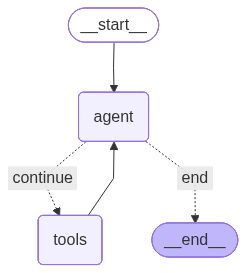

In [15]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            graph.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 6. ReAct Agent 사용해보기

이제 완성된 ReAct Agent를 실제로 사용해봅시다!

### 사용 방법
1. **입력**: 사용자 질문을 메시지 형태로 제공
2. **실행**: `graph.stream()`으로 단계별 실행
3. **출력**: 각 단계별 결과 확인


In [16]:
# 스트림을 예쁘게 출력하는 헬퍼 함수
def print_stream(stream):
    """
    그래프 실행 스트림을 보기 좋게 출력하는 함수
    """
    for step_output in stream:
        # 각 단계의 메시지 출력
        message = step_output["messages"][-1]

        if isinstance(message, tuple):
            print(message)
        else:
            # 메시지 타입에 따라 다르게 출력
            message.pretty_print()


### 예시 1: 날씨 조회

In [17]:
# 입력 메시지 설정
inputs = {"messages": [("user", "서울의 날씨가 어떤가요?")]}

print("ReAct Agent 실행 시작!\n")

try:
    # 그래프 실행 (스트림 모드로 단계별 확인)
    stream = graph.stream(inputs, stream_mode="values")
    print_stream(stream)

    print("\n첫 번째 예시 완료!")

except Exception as e:
    print(f"오류 발생: {str(e)}")
    print("API 키가 올바르게 설정되었는지 확인해주세요.")


ReAct Agent 실행 시작!

================================ Human Message =================================

서울의 날씨가 어떤가요?
AI 모델 노드 실행 중...
  총 2개의 메시지를 모델에 전달


/Users/gyoungwon-cho/dev/github/course_LLM/3. LangChain/2. multi_agents/.venv/lib/python3.13/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=4f0543d5-bfc4-4997-ac9d-51570a7ff08a; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=720dba97-9445-4592-bf84-f1a2c2864a6b; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=f5b66c42-8461-49d2-a2f8-c16f4d20cc11; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=7e075607-2c23-42de-8cba-2b152faac3ef; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=0f4a0c0a-6857-4f60-9de4-9b66e474ef26; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=926bbb7b-b9b5-4bfe-826c-d

  AI 응답 생성 완료 (도구 호출: 1개)
  1개의 도구 호출이 있으므로 계속 진행합니다
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_DiT7xWdqQD2tuZBJBCvEJ0vX)
 Call ID: call_DiT7xWdqQD2tuZBJBCvEJ0vX
  Args:
    location: 서울
도구 노드 실행 중...
  get_weather 도구 호출: {'location': '서울'}
  결과: 서울의 날씨: 맑음, 기온 20°C, 습도 60%
================================= Tool Message =================================
Name: get_weather

"\uc11c\uc6b8\uc758 \ub0a0\uc528: \ub9d1\uc74c, \uae30\uc628 20\u00b0C, \uc2b5\ub3c4 60%"
AI 모델 노드 실행 중...
  총 4개의 메시지를 모델에 전달


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=926bbb7b-b9b5-4bfe-826c-d044e1067c70; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=fe1e47d5-5ff8-4431-860c-d4662f67eafd; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=fe1e47d5-5ff8-4431-860c-d4662f67eafd; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=d8d8687e-6996-4c4d-8619-cbe8d19e6037; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=d8d8687e-6996-4c4d-8619-cbe8d19e6037; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=0f4a0c0a-6857-4f60-9de4-9b66e474ef26; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=6bd78df5-dada-4bd1-a087-604365eed376; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=67b92627-1191-4302-8296-4817034c4b46; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id

  AI 응답 생성 완료 (도구 호출: 0개)
  도구 호출이 없으므로 대화를 종료합니다
================================== Ai Message ==================================

서울의 현재 날씨는 맑고, 기온은 20°C, 습도는 60%입니다. 더 자세한 정보가 필요하시면 바람 속도나 체감 온도, 강수 확률 등도 알려드릴게요.

첫 번째 예시 완료!


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=b8ecce75-2f90-4f19-ac36-410614599576; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=08b7e026-d8bc-4991-a546-d7f3a6a0dab3; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=08b7e026-d8bc-4991-a546-d7f3a6a0dab3; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=8b21b660-4665-480b-8dfc-592b10ab332c; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=8b21b660-4665-480b-8dfc-592b10ab332c; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=3d0809b2-31aa-4df7-9ad4-2cb4e41e1953; trace=4f0543d5-bfc4-4997-ac9d-51570a7ff08a,id=4f0543d5-bfc4-4997-ac9d-51570a7ff08a; trace=454eaa68-1c74-4204-b483-8ac5b30d0079,id=454eaa68-1c74-4204-b483-8ac5b30d0079; trace=454eaa68-1c74-4204-b483-8ac5b30d0079,id

### 예시 2: 복합 질문 (시간 + 계산)

In [18]:
inputs2 = {
    "messages": [
        ("user", "현재 시간을 알려주고, 25 * 4 + 10을 계산해주세요.")
    ]
}

print("복합 질문 처리 시작!\n")

try:
    stream2 = graph.stream(inputs2, stream_mode="values")
    print_stream(stream2)

    print("\n두 번째 예시 완료!")

except Exception as e:
    print(f"오류 발생: {str(e)}")


복합 질문 처리 시작!

================================ Human Message =================================

현재 시간을 알려주고, 25 * 4 + 10을 계산해주세요.
AI 모델 노드 실행 중...
  총 2개의 메시지를 모델에 전달
  AI 응답 생성 완료 (도구 호출: 2개)
  2개의 도구 호출이 있으므로 계속 진행합니다
================================== Ai Message ==================================
Tool Calls:
  get_current_time (call_JmX5wlyyyMKUXzDnfyNLGaq7)
 Call ID: call_JmX5wlyyyMKUXzDnfyNLGaq7
  Args:
  calculator (call_Rjvrx1UJhajLucYSkDZhstLm)
 Call ID: call_Rjvrx1UJhajLucYSkDZhstLm
  Args:
    expression: 25 * 4 + 10
도구 노드 실행 중...
  get_current_time 도구 호출: {}
  결과: 현재 시간: 2025년 10월 19일 22시 00분
  calculator 도구 호출: {'expression': '25 * 4 + 10'}
  결과: 계산 결과: 25 * 4 + 10 = 110
================================= Tool Message =================================
Name: calculator

"\uacc4\uc0b0 \uacb0\uacfc: 25 * 4 + 10 = 110"
AI 모델 노드 실행 중...
  총 5개의 메시지를 모델에 전달
  AI 응답 생성 완료 (도구 호출: 0개)
  도구 호출이 없으므로 대화를 종료합니다
================================== Ai Message =============================

### 예시 3: 일반 대화 (도구 사용 없음)

In [19]:
inputs3 = {
    "messages": [
        ("user", "안녕하세요! LangGraph에 대해 간단히 설명해주세요.")
    ]
}

print("일반 대화 처리 시작!\n")

try:
    stream3 = graph.stream(inputs3, stream_mode="values")
    print_stream(stream3)

    print("\n세 번째 예시 완료!")

except Exception as e:
    print(f"오류 발생: {str(e)}")


일반 대화 처리 시작!

================================ Human Message =================================

안녕하세요! LangGraph에 대해 간단히 설명해주세요.
AI 모델 노드 실행 중...
  총 2개의 메시지를 모델에 전달
  AI 응답 생성 완료 (도구 호출: 0개)
  도구 호출이 없으므로 대화를 종료합니다
================================== Ai Message ==================================

간단히 말해, LangGraph는 언어 데이터를 그래프 형태로 표현하고 다루는 방식이나 시스템입니다. 노드와 간선으로 언어 간의 관계를 직관적으로 표현해 복합적인 질의를 처리하고 추론하는 데 유용합니다.

주요 포인트
- 구성 요소
  - 노드: 단어, 구, 개념, 문서 등 언어와 관련된 단위
  - 간선: 의미 관계나 번역 대응 등 관계들(동의어/반의어, 상위어-하위어, 공출현, 번역 매핑 등)
- 왜 유용한가
  - 복잡한 언어 관계를 한 눈에 파악하고 탐색하기 쉽습니다.
  - 다국어 연결이나 지식 연결에 강해 다국어 검색/번역 보조에 적합합니다.
  - 그래프 신경망(GNN)으로 노드 간의 관계를 학습하고 추론할 수 있습니다.
- 활용 예시
  - 의미 기반 검색, 질의응답
  - 다국어 용어 매핑 및 어휘 연결
  - 번역 시스템 보조, 의미적 추천
- 구현 시 고려할 점
  - 데이터 품질과 관계 정의의 일관성
  - 그래프의 규모와 확장성 관리
  - 업데이트 및 동합성(cost of keeping the graph fresh)

간단한 예시
- 노드: "apple" (사과), "fruit" (과일), "red" (빨강)
- 간선: "apple" is_a "fruit", "apple" has_color "red"

원하시면 특정 LangGraph 플랫폼이나 도구를 염두에 두고 더 자세한 설명이나 사용 사례를 맞춤으로 정리해 